# Bulk-crystal CXR — analysis driver

Thin driver for the Monte-Carlo CXR pipeline; the heavy lifting lives in `src/`:

- **`cxr_sweep.py`** — a parameter `Sweep` (each parameter a single value *or* a
  range) expanded into cases.
- **`cxr_run.py`** — run the cases with checkpointing + per-chunk feedback.
- **`cxr_results.py`** — post-processing, the `best_azimuth` reduction, the stats table.
- **`cxr_plots.py`** — all the figures.
- **`cxr_montecarlo.py` / `timepix_response.py`** — the physics + detector model.

Set everything in the **PARAMETERS** cell, then run top to bottom.

In [ ]:
# imports: src/ on the path, then the analysis modules (run from the repo root)
import sys

sys.path.insert(0, "src")

# Interactive click-through viewer (browse) needs the ipympl backend. For a clean
# PDF export (export_pdf.py), switch this to `%matplotlib inline` -- browse() then
# falls back to drawing every tilt stacked, so all the figures still render.
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from cxr_sweep import Sweep, build_cases, geometry_table
from cxr_results import Settings, records, best_azimuth, show_summary, filter_results
from cxr_plots import (
    browse,
    plot_by_energy,
    plot_peak_vs_tilt,
    stream_chunk,
    plot_timepix_efficiency,
    plot_timepix_detected,
    plot_timepix_poisson,
    plot_heatmaps,
    plot_full_spectrum,
)
from cxr_run import run_sweep

SyntaxError: invalid syntax (3397197969.py, line 22)

In [ ]:
# ============================================================================
#  PARAMETERS -- each physical quantity is a SINGLE VALUE (fixed) or a
#  LIST/ARRAY (swept). build_cases takes the Cartesian product over the swept
#  ones; nothing else needs to change to switch a parameter between fixed and
#  swept.
# ============================================================================

settings = Settings(
    beam_current_na=5.0,
    n_electrons=300,  # transport electrons per line spectrum
    n_electrons_brem=100,  # transport electrons per background
    apply_detector_qe=True,
    convolve_with_det=False,
    brem_source="mc",  # "mc" | "external" | "none"
)

# When tilt_azim_deg is swept, collapse it: for each (polar tilt, energy) keep
# only the azimuth with the highest spectral peak max(spectrum). False -> show
# every azimuth.
COLLAPSE_AZIMUTH = True

# Material Choices:
# "hopg" | "diamond" | "silicon" | "ptse2"
# "mose2" | "wse2" | "hfse2" | "ws2"

MATERIAL = "hopg"

match MATERIAL:
    case "hopg":
        sweep = Sweep(
            material=MATERIAL,
            thickness_ang=17e4,  # 17 um
            energy_keV=[30, 45, 60],
            tilt_deg=np.linspace(-89, 89, 40, endpoint=True),
            tilt_azim_deg=np.linspace(-89, -0.1, 20, endpoint=True),
            theta_obs_deg=90.0,  # detector polar angle (fixed)
            e_grid_eV=np.arange(50.0, 2500.0, 1.0),
            E_grid_brem=np.arange(
                0.0, 60000.0, 30.0
            ),  # brem: coarse + WIDE (or omit -> auto to 60 keV)
        )

    case "diamond":
        sweep = Sweep(
            material=MATERIAL,
            thickness_ang=10e4,  # 2 um
            energy_keV=[30, 45, 60],
            tilt_deg=np.linspace(-89, 89, 30, endpoint=True),
            tilt_azim_deg=np.linspace(-89, -0.1, 15, endpoint=True),
            theta_obs_deg=90.0,  # detector polar angle (fixed)
            e_grid_eV=np.arange(50.0, 3500.0, 2.0),
            E_grid_brem=np.arange(
                0.0, 60000.0, 30.0
            ),  # brem: coarse + WIDE (or omit -> auto to 60 keV)
        )

    case "silicon":
        sweep = Sweep(
            material=MATERIAL,
            thickness_ang=1e4,  # 2 um
            energy_keV=[30, 45, 60],
            tilt_deg=np.linspace(-89, 89, 40, endpoint=True),
            tilt_azim_deg=np.linspace(-89, -0.1, 15, endpoint=True),
            theta_obs_deg=90.0,  # detector polar angle (fixed)
            e_grid_eV=np.arange(50.0, 2500.0, 1.0),
            E_grid_brem=np.arange(
                0.0, 60000.0, 30.0
            ),  # brem: coarse + WIDE (or omit -> auto to 60 keV)
        )

    case "mose2":
        sweep = Sweep(
            material=MATERIAL,
            thickness_ang=1e4,  # 2 um
            energy_keV=[30, 45, 60],
            tilt_deg=np.linspace(-89, 89, 40, endpoint=True),
            tilt_azim_deg=np.linspace(-89, -0.1, 15, endpoint=True),
            theta_obs_deg=90.0,  # detector polar angle (fixed)
            e_grid_eV=np.arange(50.0, 2500.0, 1.0),
            E_grid_brem=np.arange(
                0.0, 60000.0, 30.0
            ),  # brem: coarse + WIDE (or omit -> auto to 60 keV)
        )

    case "wse2":
        sweep = Sweep(
            material=MATERIAL,
            thickness_ang=1e4,  # 1 um
            energy_keV=[30, 45, 60],
            tilt_deg=np.linspace(-89, 89, 30, endpoint=True),
            tilt_azim_deg=np.linspace(-85, -0.1, 15),
            theta_obs_deg=90.0,  # detector polar angle (fixed)
            E_grid_line=np.arange(
                50.0, 3500.0, 3.0
            ),  # lines: fine + NARROW (cover where your lines end)
            E_grid_brem=np.arange(
                0.0, 60000.0, 25.0
            ),  # brem: coarse + WIDE (or omit -> auto to 60 keV)
        )

    case "ptse2":
        sweep = Sweep(
            material=MATERIAL,
            thickness_ang=1e4,  # 1 um
            energy_keV=[30, 45, 60],
            tilt_deg=np.linspace(-89, 89, 30, endpoint=True),
            tilt_azim_deg=np.linspace(-85, -0.1, 15),
            theta_obs_deg=90.0,  # detector polar angle (fixed)
            E_grid_line=np.arange(
                50.0, 3500.0, 3.0
            ),  # lines: fine + NARROW (cover where your lines end)
            E_grid_brem=np.arange(
                0.0, 60000.0, 25.0
            ),  # brem: coarse + WIDE (or omit -> auto to 60 keV)
        )

    case "zrse2":
        sweep = Sweep(
            material=MATERIAL,  # "mose2" | "graphite" | "diamond" | "silicon"
            thickness_ang=1e4,  # 1 um
            energy_keV=[30, 45, 60],
            tilt_deg=np.linspace(-89, 89, 30, endpoint=True),
            tilt_azim_deg=np.linspace(
                -85, -0.1, 15, endpoint=True
            ),  # swept: azimuth range
            theta_obs_deg=90.0,  # detector polar angle (fixed)
            E_grid_line=np.arange(
                50.0, 3500.0, 3.0
            ),  # lines: fine + NARROW (cover where your lines end)
            E_grid_brem=np.arange(
                0.0, 60000.0, 25.0
            ),  # brem: coarse + WIDE (or omit -> auto to 60 keV)
        )

    case "ws2":
        sweep = Sweep(
            material=MATERIAL,  # "mose2" | "graphite" | "diamond" | "silicon"
            thickness_ang=1e4,  # 1 um
            energy_keV=[30, 45, 60],
            tilt_deg=np.linspace(-89, 89, 30, endpoint=True),
            tilt_azim_deg=np.linspace(
                -85, -0.1, 15, endpoint=True
            ),  # swept: azimuth range
            theta_obs_deg=90.0,  # detector polar angle (fixed)
            E_grid_line=np.arange(
                50.0, 3500.0, 3.0
            ),  # lines: fine + NARROW (cover where your lines end)
            E_grid_brem=np.arange(
                0.0, 60000.0, 25.0
            ),  # brem: coarse + WIDE (or omit -> auto to 60 keV)
        )

    case "mos2":
        sweep = Sweep(
            material=MATERIAL,  # "mose2" | "graphite" | "diamond" | "silicon"
            thickness_ang=1e4,  # 1 um
            energy_keV=[30, 45, 60],
            tilt_deg=np.linspace(-89, 89, 30, endpoint=True),
            tilt_azim_deg=np.linspace(
                -85, -0.1, 15, endpoint=True
            ),  # swept: azimuth range
            theta_obs_deg=90.0,  # detector polar angle (fixed)
            E_grid_line=np.arange(
                50.0, 3500.0, 3.0
            ),  # lines: fine + NARROW (cover where your lines end)
            E_grid_brem=np.arange(
                0.0, 60000.0, 25.0
            ),  # brem: coarse + WIDE (or omit -> auto to 60 keV)
        )

In [ ]:
# build the case list and preview the geometry
cases = build_cases(sweep, settings.n_electrons, settings.n_electrons_brem)
print(f"{len(cases)} cases across {len({c['name'] for c in cases})} configs")
display(geometry_table(cases))

1800 cases across 600 configs


,config,refl,t [um],polar [deg],azim [deg],energies [keV],line grid,brem grid,theta_obs [deg],dOmega [sr]
0,diamond 10um pol=-89 az=-89,50,10.0,-89.0,-89.00,"[30.0, 45.0, 60.0]",0.05-2.499 keV @ 1 eV,0-59.97 keV @ 30 eV,90.0,0.001239
1,diamond 10um pol=-89 az=-82.65,50,10.0,-89.0,-82.65,"[30.0, 45.0, 60.0]",0.05-2.499 keV @ 1 eV,0-59.97 keV @ 30 eV,90.0,0.001239
2,diamond 10um pol=-89 az=-76.3,50,10.0,-89.0,-76.30,"[30.0, 45.0, 60.0]",0.05-2.499 keV @ 1 eV,0-59.97 keV @ 30 eV,90.0,0.001239
3,diamond 10um pol=-89 az=-69.95,50,10.0,-89.0,-69.95,"[30.0, 45.0, 60.0]",0.05-2.499 keV @ 1 eV,0-59.97 keV @ 30 eV,90.0,0.001239
4,diamond 10um pol=-89 az=-63.6,50,10.0,-89.0,-63.60,"[30.0, 45.0, 60.0]",0.05-2.499 keV @ 1 eV,0-59.97 keV @ 30 eV,90.0,0.001239
...,...,...,...,...,...,...,...,...,...,...
595,diamond 10um pol=89 az=-25.5,50,10.0,89.0,-25.50,"[30.0, 45.0, 60.0]",0.05-2.499 keV @ 1 eV,0-59.97 keV @ 30 eV,90.0,0.001239
596,diamond 10um pol=89 az=-19.15,50,10.0,89.0,-19.15,"[30.0, 45.0, 60.0]",0.05-2.499 keV @ 1 eV,0-59.97 keV @ 30 eV,90.0,0.001239
597,diamond 10um pol=89 az=-12.8,50,10.0,89.0,-12.80,"[30.0, 45.0, 60.0]",0.05-2.499 keV @ 1 eV,0-59.97 keV @ 30 eV,90.0,0.001239
598,diamond 10um pol=89 az=-6.45,50,10.0,89.0,-6.45,"[30.0, 45.0, 60.0]",0.05-2.499 keV @ 1 eV,0-59.97 keV @ 30 eV,90.0,0.001239


In [ ]:
results = {}
run_sweep(
    cases,
    results,
    on_chunk=lambda batch: stream_chunk(
        results, batch, settings, collapse_azimuth=COLLAPSE_AZIMUTH
    ),
)

# The streamed tables print live above; click through the 2x2 best-azimuth plots
# (one figure per polar tilt) here once the run is done.
browse(filter_results(results, cases), settings, kind="chunk")

resumed 120 diamond cases from checkpoints\diamond.pkl
1680 of 1800 cases to run (120 cached)

=== cached: 10 um, tilt -89 deg (already computed) ===
unity QE, beam current 5 nA  |  peak/bg = EDS-convolved peak height / background at the peak


config                                                         \
  material thickness polar [deg] azimuth [deg] Ee [keV] line [eV]   
0  diamond      10um       -89.0         -38.2     30.0     212.0   
1  diamond      10um       -89.0          -0.1     45.0      64.0   
2  diamond      10um       -89.0          -0.1     60.0      64.0   

                                                                   
  peak [Phs/eV/s] peak/bg line [cts/s] brem [cts/s] total [cts/s]  
0            0.34    0.20        171.7       1786.7        1958.4  
1            0.29    0.19        181.1       1489.1        1670.1  
2            0.37    0.23        187.3       2641.9        2829.2


=== cached: 10 um, tilt -84.4359 deg (already computed) ===
unity QE, beam current 5 nA  |  peak/bg = EDS-convolved peak height / background at the peak


config                                                         \
  material thickness polar [deg] azimuth [deg] Ee [keV] line [eV]   
0  diamond      10um       -84.4         -50.9     30.0      66.0   
1  diamond      10um       -84.4         -50.9     45.0      72.0   
2  diamond      10um       -84.4         -50.9     60.0      78.0   

                                                                   
  peak [Phs/eV/s] peak/bg line [cts/s] brem [cts/s] total [cts/s]  
0            0.45    0.24        254.1       2588.7        2842.8  
1            0.47    0.30        282.4       3448.4        3730.8  
2            0.51    0.37        300.5       4349.0        4649.4

cases:   0%|          | 0/1680 [00:00<?, ?it/s]

...

c:\dev\cxr_model\src\cxr_feranchuk_spence.py:302: RuntimeWarning: divide by zero encountered in divide
  lam = HC_EV_ANG / photon_E_eV



=== 10 um, tilt -75.3077 deg done -- 2/38 tilt-groups ===
unity QE, beam current 5 nA  |  peak/bg = EDS-convolved peak height / background at the peak


config                                                         \
  material thickness polar [deg] azimuth [deg] Ee [keV] line [eV]   
0  diamond      10um       -75.3         -50.9     30.0     244.0   
1  diamond      10um       -75.3         -50.9     45.0     251.0   
2  diamond      10um       -75.3         -50.9     60.0     181.0   

                                                                   
  peak [Phs/eV/s] peak/bg line [cts/s] brem [cts/s] total [cts/s]  
0            0.43    0.14        297.7       3436.7        3734.3  
1            0.39    0.16        308.4       4623.3        4931.7  
2            0.36    0.23        295.6       5209.7        5505.4

c:\dev\cxr_model\src\cxr_feranchuk_spence.py:302: RuntimeWarning: divide by zero encountered in divide
  lam = HC_EV_ANG / photon_E_eV


KeyboardInterrupt: 

unity QE, beam current 5 nA  |  peak/bg = EDS-convolved peak height / background at the peak


config                                                         \
    material thickness polar [deg] azimuth [deg] Ee [keV] line [eV]   
0      MoSe2       2um       -89.0         -59.3     45.0      70.0   
1      MoSe2       2um       -89.0         -59.3     60.0      68.0   
2      MoSe2       2um       -89.0          59.3     30.0      70.0   
3      MoSe2       2um       -84.4         -65.3     60.0      75.0   
4      MoSe2       2um       -84.4          59.3     30.0      71.0   
..       ...       ...         ...           ...      ...       ...   
115    MoSe2       2um        84.4           0.0     45.0      79.0   
116    MoSe2       2um        84.4          11.9     30.0      81.0   
117    MoSe2       2um        89.0         -11.9     30.0      82.0   
118    MoSe2       2um        89.0          -5.9     45.0      81.0   
119    MoSe2       2um        89.0           0.0     60.0      80.0   

                                                                     
    peak [Phs/eV/s] peak/bg line [cts/s] brem [cts/s] total [cts/s]  
0              0.90    0.23        173.8       1299.1        1472.9  
1              1.13    0.24        185.1       1739.2        1924.3  
2              0.79    0.16        169.6       1898.2        2067.9  
3              1.70    0.32        279.7       2308.6        2588.4  
4              1.48    0.20        303.3       2956.8        3260.1  
..              ...     ...          ...          ...           ...  
115            0.11    0.13        103.4       1027.6        1131.0  
116            0.06    0.07         55.2       1141.2        1196.3  
117            0.03    0.27         23.7        558.9         582.5  
118            0.07    0.17         57.9        750.8         808.7  
119            0.07    0.12         75.7        485.1         560.8  

[120 rows x 11 columns]

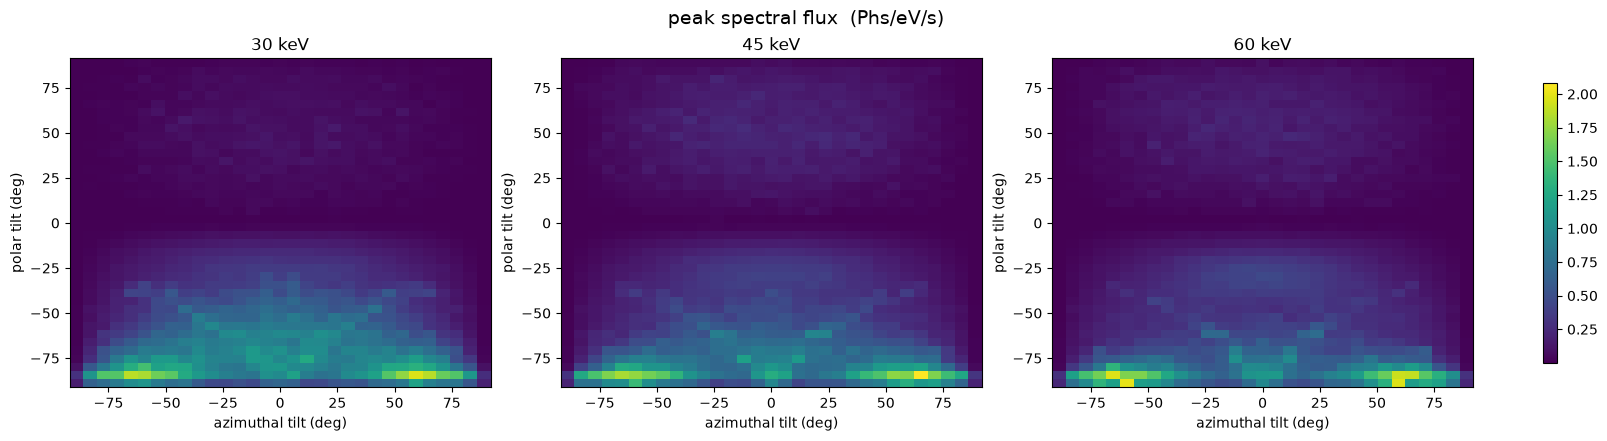

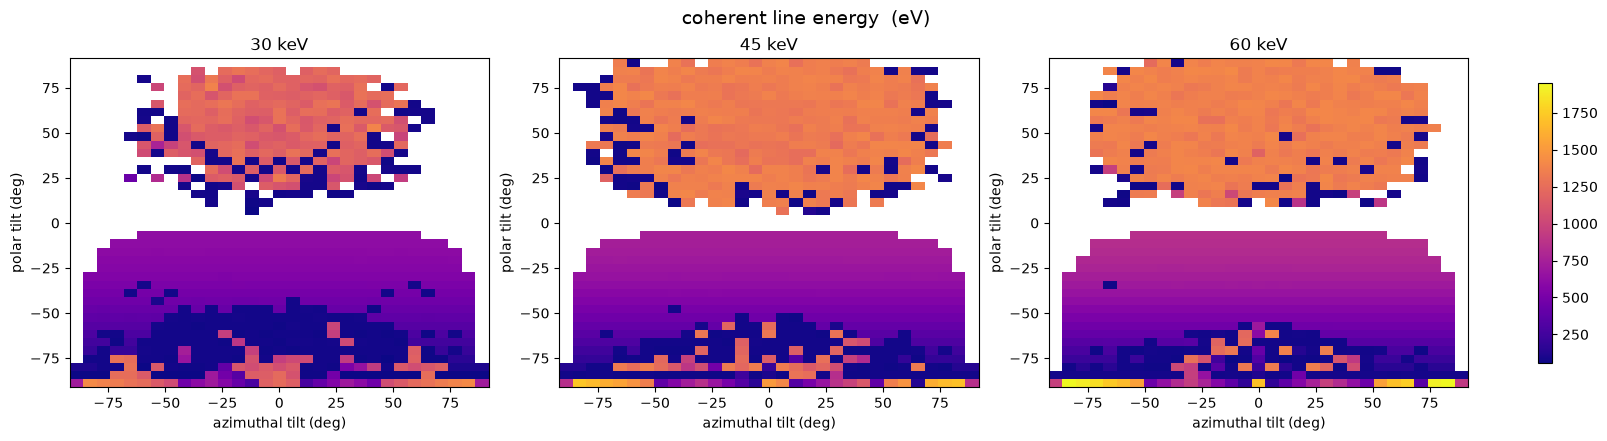

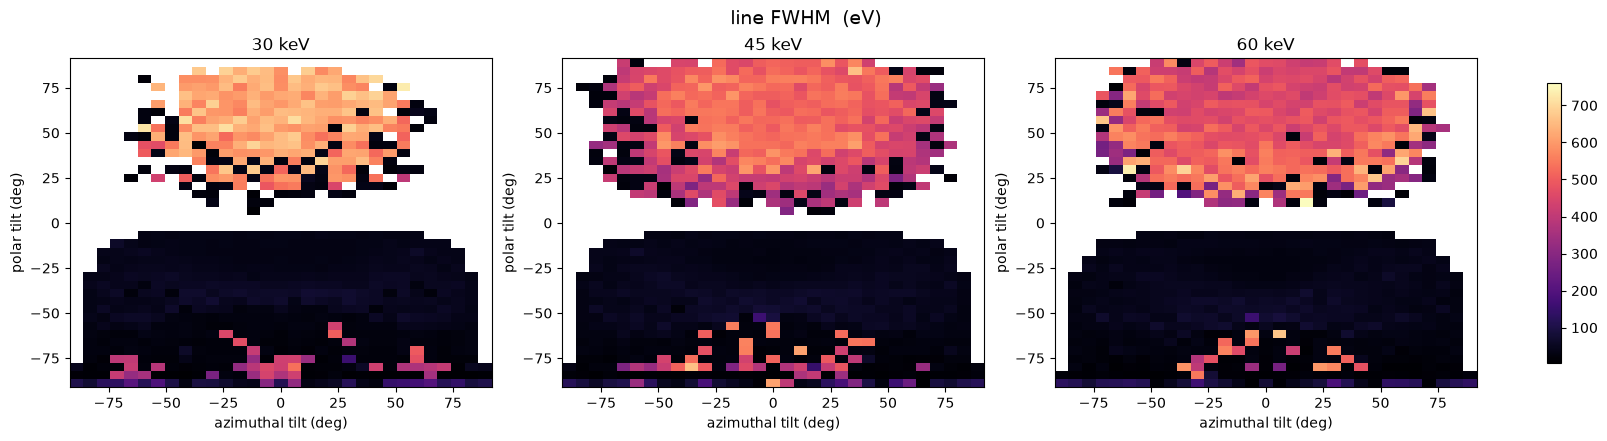

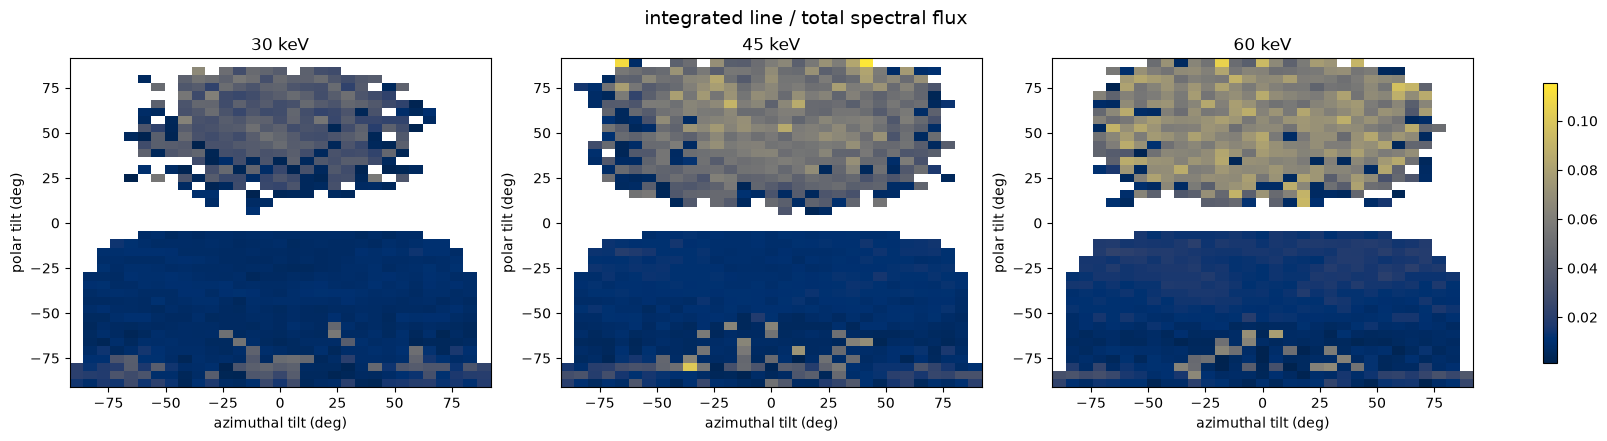

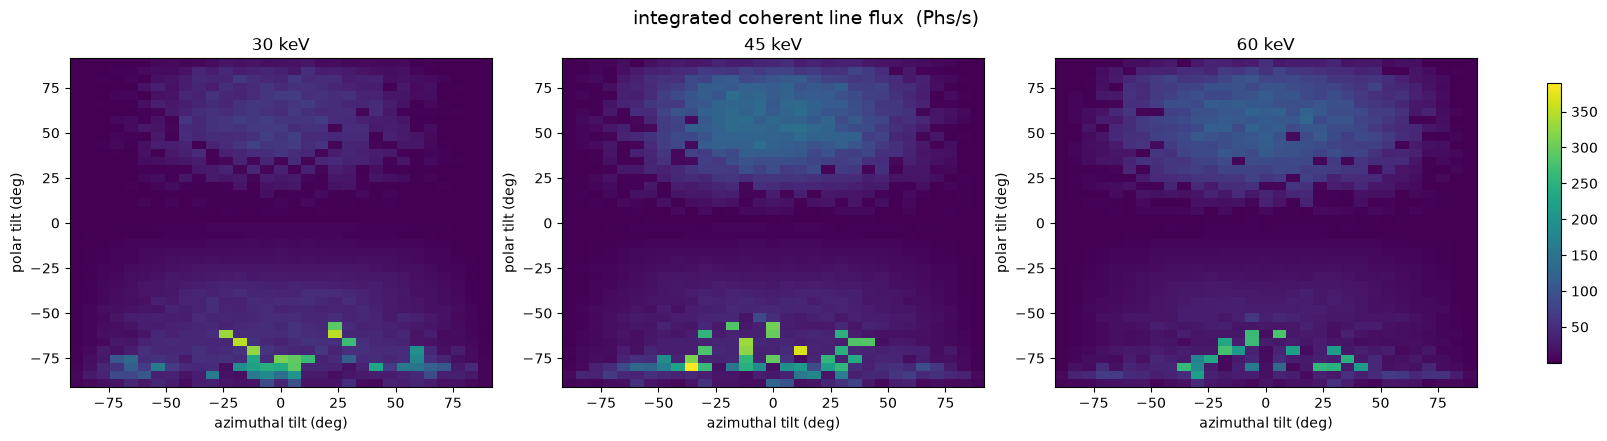

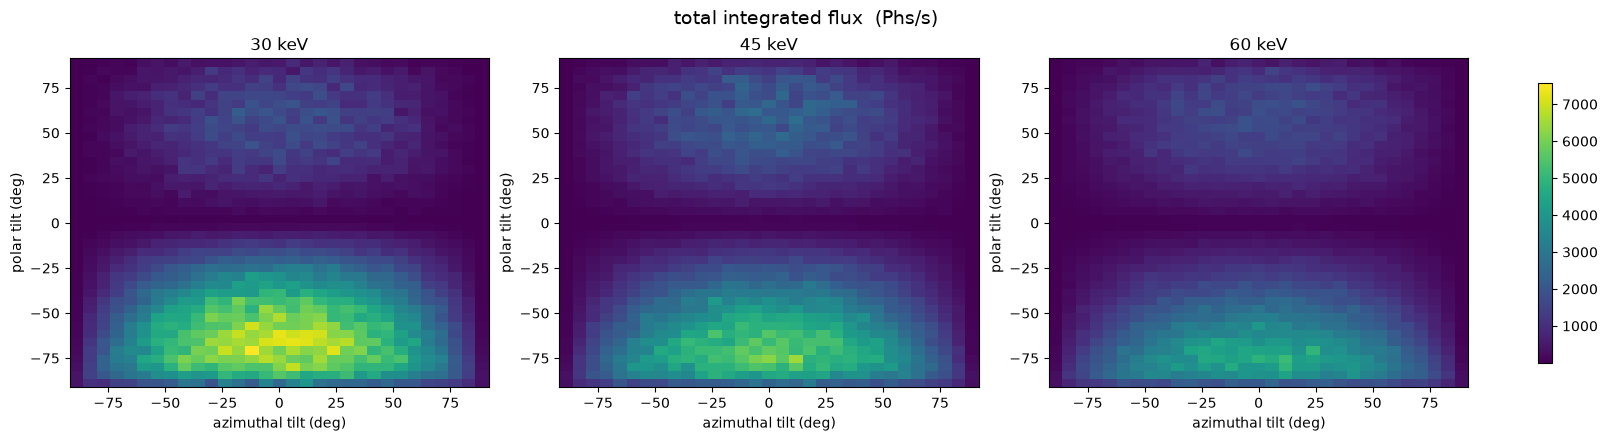

In [ ]:
# Photon-counting stats. best_azimuth collapses the azimuth sweep to one row per
# (polar tilt, energy); set COLLAPSE_AZIMUTH=False above for every azimuth.
res = filter_results(results, cases)  # dict, current sweep only

plot_heatmaps(
    res, settings, cases=cases, line_metric="prominence"
)  # dominant line -> smoother maps

recs = best_azimuth(records(res)) if COLLAPSE_AZIMUTH else records(res)
show_summary(recs, settings)  # list in

## Timepix3 detector response

Push the intrinsic spectra through a forward model of the actual 2×2 Timepix3
(Si sensor): photoabsorption → charge sharing → per-pixel threshold counting →
ToT energy noise → Poisson statistics (`timepix_response.py`). The ~1.9 keV
counting threshold sits above much of the MoSe₂ signal, so expect strong sub-2
keV suppression and a charge-loss low-energy tail.

> **⚠ Set `TPX_THICKNESS_UM` / `TPX_BIAS_V` to the real quad values** —
> σ_diff ∝ 1/√(bias) is the single most sensitive knob.

In [ ]:
# Timepix3 forward-model figures. Hardware is a PLACEHOLDER -- set to the real
# quad values.
TPX_THICKNESS_UM = 300.0  ### FILL IN -- Si sensor thickness [um]
TPX_BIAS_V = 100.0  ### FILL IN -- applied bias [V]
res = filter_results(results, cases)  # current sweep only

# single-figure diagnostics (left as-is -- not many of these)
plot_timepix_efficiency(thickness_um=TPX_THICKNESS_UM, bias_v=TPX_BIAS_V)
plot_timepix_poisson(
    res,
    settings,
    integration_s=600.0,
    thickness_um=TPX_THICKNESS_UM,
    bias_v=TPX_BIAS_V,
)

# Click-through viewers -- one interactive figure each, paged by polar tilt.
# (Under %matplotlib inline these fall back to every tilt stacked, for the PDF.)
browse(
    res,
    settings,
    kind="timepix",  # Timepix detected (solid) vs incident (dotted), log
    thickness_um=TPX_THICKNESS_UM,
    bias_v=TPX_BIAS_V,
)
browse(res, settings, kind="by_energy")  # intrinsic | detector-convolved line spectra
browse(res, settings, kind="full")  # full measured range out to the beam energy, log